# ReproNLP 2026 — Analysis Notebook

This notebook reproduces all tables and in-text statistics reported in the paper:

| Section | Content |
|---------|----------|
| Table 1 | Mean scores and standard deviations across all studies |
| Table 2 | Inter-annotator agreement (Krippendorff's α) |
| Table 3 | Pairwise system comparisons (this study) |
| Table 4 | QAG vs PAQ t-test comparison across all studies |
| Table 5 | Pairwise CV* reproducibility across studies |
| Tables 6 & 7 | QRA3 input files (consumed by external tool) |
| §Discussion: Val impact | Pairwise comparisons on val-filtered data |
| §Discussion: Item-level correlation | Pearson/Spearman/Kendall between original and this study |
| Poster: QAG systems output| Identify examples of QAG output |
| Poster: Performance with full vs. cleaned data | Answer relevance of PAQ and QAG with full vs. cleaned data"
| Poster: IAA collapse | Calculate pairwise IAA |


## Imports and Global Constants

In [1]:
import os
import warnings

import krippendorff
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kendalltau
from typing import Optional

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# ---------------------------------------------------------------------------
# Dataset constants
# ---------------------------------------------------------------------------

DATASET_URLS = {
    'yao2022':      'https://raw.githubusercontent.com/mcmarius/ReproNLP-2024/2eae8eb13b70bc92aeeb5e1b2efd038809e63597/data/ACL_StoryQG_Human_Evaluation%20-%20Integrated_Results.csv',
    'braun2025':    'https://raw.githubusercontent.com/Responsible-NLP/ReproHum-0031-01/da65c5cd0efb3b1f1e4e27babd15eb1fc28dccb3/reproduction.csv',
    'florescu2024': 'https://raw.githubusercontent.com/mcmarius/ReproNLP-2024/2eae8eb13b70bc92aeeb5e1b2efd038809e63597/data/stories_combined.csv',
}

# Internal criterion column names used across all DataFrames
CRITERIA_COLUMNS = ['readability', 'relevancy_q', 'relevancy_a']

# Maps internal column names to full display names (used in QRA export)
CRITERIA_DISPLAY_NAMES = {
    'readability': 'Readability',
    'relevancy_q': 'Question Relevancy',
    'relevancy_a': 'Answer Relevancy',
}

# Florescu dataset uses different column names that need explicit remapping
FLORESCU_COLUMN_MAP = {
    'readability_new': 'readability',
    'relevancy_q_new': 'relevancy_q',
    'relevancy_a_new': 'relevancy_a',
}

# Output columns for QRA format files
QRA_COLUMNS = ['Key', 'Study', 'Experiment', 'System', 'Criterion', 'Result']

# ---------------------------------------------------------------------------
# Display / ordering constants shared across all tables
# ---------------------------------------------------------------------------

# Controls the row order of studies in every output table
STUDY_ORDER = [
    'Yao et al. (2022)',
    'Florescu et al. (2024)',
    'Braun (2025)',
    'This study',
]

# Controls the column order of systems in every output table
SYSTEM_ORDER = ['QAG', 'PAQ', 'GT']

# Controls the row order of criteria in every output table
CRITERION_ORDER = ['Readability', 'Question Relevance', 'Answer Relevance']

# Maps internal column names to human-readable criterion labels
CRITERION_LABELS = {
    'readability': 'Readability',
    'relevancy_q': 'Question Relevance',
    'relevancy_a': 'Answer Relevance',
}

# Short labels used in compact tables (e.g. IAA table)
CRITERION_SHORT_LABELS = {
    'readability': 'Read.',
    'relevancy_q': 'Q. Rel.',
    'relevancy_a': 'A. Rel.',
}

# Maps internal dataset keys to display names used in paper tables
STUDY_DISPLAY_MAP = {
    'yao2022':      'Yao et al. (2022)',
    'florescu2024': 'Florescu et al. (2024)',
    'braun2025':    'Braun (2025)',
    'this_study':   'This study',
}

# System pairs tested; order encodes the directional hypothesis (sys1 > sys2)
COMPARISON_PAIRS = [('GT', 'QAG'), ('QAG', 'PAQ'), ('GT', 'PAQ')]

# Criteria paired with short display labels used in comparison tables
CRITERIA_FOR_COMPARISON = [
    ('readability', 'Readability'),
    ('relevancy_q', 'Question Rel.'),
    ('relevancy_a', 'Answer Rel.'),
]

# Significance threshold used throughout
ALPHA = 0.05

# ---------------------------------------------------------------------------
# CV* constants
# ---------------------------------------------------------------------------

# Maps internal criterion column names to the display labels used in the
# CV* table (must align with CRITERION_ORDER)
CV_CRITERION_LABELS = {
    'readability': 'Readability',
    'relevancy_q': 'Question Relevance',
    'relevancy_a': 'Answer Relevance',
}

# Study order specific to the CV* table
CV_STUDY_ORDER = [
    'Florescu original (wrong)',
    'Florescu recomputed',
    'Braun 2025',
    'this study',
]

# Pre-computed (wrong) CV* values as reported in the Florescu paper
# (calculated without the required 0-shift on the Likert scale)
FLORESCU_WRONG_CVS = [
    {'Criterion': 'Readability',        'Study': 'Florescu original (wrong)',
     'QAG':  4.10, 'PAQ':  2.18, 'GT': 4.95},
    {'Criterion': 'Question Relevance', 'Study': 'Florescu original (wrong)',
     'QAG': 13.58, 'PAQ': 14.59, 'GT': 4.35},
    {'Criterion': 'Answer Relevance',   'Study': 'Florescu original (wrong)',
     'QAG': 21.90, 'PAQ': 19.66, 'GT': 7.94},
]

## Helper Functions

All reusable functions are defined here and shared across table sections below.

In [2]:
# ---------------------------------------------------------------------------
# Data download and loading
# ---------------------------------------------------------------------------

def download_dataset(name: str, dest_dir: str = './annotations', force: bool = False) -> str:
    """Download a dataset CSV from GitHub if not already present locally.

    Args:
        name:     Dataset key from DATASET_URLS (e.g. 'yao2022').
        dest_dir: Directory where the file will be saved.
        force:    If True, re-download even if the file already exists.

    Returns:
        Path to the local CSV file.
    """
    if name not in DATASET_URLS:
        raise KeyError(f"Unknown dataset '{name}'. Available: {list(DATASET_URLS.keys())}")

    dest_path = os.path.join(dest_dir, f'{name}.csv')

    if os.path.exists(dest_path) and not force:
        print(f"[download] '{name}' already present at '{dest_path}', skipping.")
        return dest_path

    url = DATASET_URLS[name]
    print(f"[download] Downloading '{name}' from {url} ...")
    response = requests.get(url)
    response.raise_for_status()

    os.makedirs(dest_dir, exist_ok=True)
    with open(dest_path, 'w', encoding='utf-8') as f:
        f.write(response.text)

    print(f"[download] Saved to '{dest_path}'.")
    return dest_path


def download_all_datasets(dest_dir: str = './annotations', force: bool = False) -> dict[str, str]:
    """Download all datasets defined in DATASET_URLS."""
    return {
        name: download_dataset(name, dest_dir=dest_dir, force=force)
        for name in DATASET_URLS
    }


def load_and_normalise(path: str, column_map: Optional[dict] = None) -> pd.DataFrame:
    """Load an annotation CSV and normalise quality-criterion column names.

    Args:
        path:       Path to the CSV file.
        column_map: Optional explicit {old_name: new_name} rename mapping.

    Returns:
        Normalised DataFrame with consistent column names.
    """
    df = pd.read_csv(path)
    df = df.rename(columns={'source': 'System'})
    df['System'] = df['System'].replace({'groundtruth': 'GT', 'Ours': 'QAG'})

    if column_map is not None:
        clashing = [new for new in column_map.values() if new in df.columns]
        df = df.drop(columns=clashing)
        return df.rename(columns=column_map)

    rename = {}
    for col in df.columns:
        lower = col.lower()
        if 'readability' in lower:
            rename[col] = 'readability'
        elif 'relevancy_q' in lower:
            rename[col] = 'relevancy_q'
        elif 'relevancy_a' in lower:
            rename[col] = 'relevancy_a'

    return df.rename(columns=rename)


# ---------------------------------------------------------------------------
# QRA export
# ---------------------------------------------------------------------------

def convert_to_qra_format(
    df: pd.DataFrame,
    study: str,
    experiment: str,
    key: str,
    criteria: Optional[list[str]] = None,
) -> pd.DataFrame:
    """Convert a normalised annotation DataFrame to QRA format.

    Aggregates item-level scores to system-level means and adds
    study metadata columns required by the QRA3 tool.

    Args:
        df:         Normalised annotation DataFrame.
        study:      Study label (e.g. 'Yao2022').
        experiment: Experiment role label (e.g. 'O', 'R1', 'R2', 'R3').
        key:        Key label grouping studies of the same experiment.
        criteria:   Criterion column names to include.

    Returns:
        DataFrame in QRA format.
    """
    df = df.copy().drop(columns=['split'], errors='ignore')
    available_criteria = [c for c in (criteria or CRITERIA_COLUMNS) if c in df.columns]

    df_melted = pd.melt(
        df,
        id_vars=['System'],
        value_vars=available_criteria,
        var_name='Criterion',
        value_name='Result',
    ).groupby(['System', 'Criterion']).mean().reset_index()

    df_melted['Experiment'] = experiment
    df_melted['Study']      = study
    df_melted['Token']      = 0
    df_melted['Key']        = key
    df_melted['Criterion']  = df_melted['Criterion'].replace(CRITERIA_DISPLAY_NAMES)

    return df_melted[QRA_COLUMNS]


def export_qra(
    frames: list[pd.DataFrame],
    path: str,
    criteria_filter: Optional[list[str]] = None,
) -> None:
    """Concatenate QRA-format DataFrames and save to CSV."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df = pd.concat(frames)
    if criteria_filter is not None:
        df = df[df['Criterion'].isin(criteria_filter)]
    df.to_csv(path, index=False)


# ---------------------------------------------------------------------------
# Table 1: mean / std summary
# ---------------------------------------------------------------------------

def melt_study_scores(df: pd.DataFrame, study_label: str) -> pd.DataFrame:
    """Reshape a wide annotation DataFrame into long format."""
    available_criteria = [c for c in CRITERIA_COLUMNS if c in df.columns]
    return (
        df
        .melt(id_vars='System', value_vars=available_criteria,
              var_name='Criterion', value_name='Result')
        .assign(Study=study_label)
    )


def build_mean_std_table(study_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Build a pivoted mean/SD summary table grouped by criterion and study."""
    long_df = (
        pd.concat([
            melt_study_scores(frame, study_label)
            for study_label, frame in study_frames.items()
        ])
        .replace({'Criterion': CRITERION_LABELS})
        .groupby(['Study', 'Criterion', 'System'])['Result']
        .agg(['mean', 'std'])
        .reset_index()
    )

    long_df['Study']  = pd.Categorical(long_df['Study'],  categories=STUDY_ORDER,  ordered=True)
    long_df['System'] = pd.Categorical(long_df['System'], categories=SYSTEM_ORDER, ordered=True)

    return (
        long_df
        .pivot(index=['Criterion', 'Study'], columns='System', values=['mean', 'std'])
        .swaplevel(axis=1)
        .sort_index(axis=1)
        .round(2)
        .reindex(CRITERION_ORDER, level=0)
    )


# ---------------------------------------------------------------------------
# Table 2: inter-annotator agreement
# ---------------------------------------------------------------------------

def compute_krippendorff_alpha(
    df: pd.DataFrame,
    criterion_col: str,
    level_of_measurement: str = 'ordinal',
) -> Optional[float]:
    """Compute Krippendorff's α for a single criterion within one study."""
    if criterion_col not in df.columns:
        return None

    df_valid = df.dropna(
        subset=[criterion_col, 'labeller_id', 'story_name', 'qa_id']
    ).copy()
    df_valid['item_id'] = (
        df_valid['story_name'].astype(str) + '_' + df_valid['qa_id'].astype(str)
    )

    if df_valid['labeller_id'].nunique() < 2:
        return None

    reliability_matrix = (
        df_valid
        .pivot_table(index='labeller_id', columns='item_id',
                     values=criterion_col, aggfunc='first')
        .to_numpy()
    )

    try:
        return krippendorff.alpha(
            reliability_data=reliability_matrix,
            level_of_measurement=level_of_measurement,
        )
    except ValueError:
        return None


def build_iaa_table(study_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Build an inter-annotator agreement table across studies and criteria."""
    rows = []
    for study_label, df in study_frames.items():
        row = {'Study': study_label}
        for criterion_col, display_name in CRITERION_SHORT_LABELS.items():
            row[display_name] = compute_krippendorff_alpha(df, criterion_col)
        rows.append(row)

    iaa_df = pd.DataFrame(rows).set_index('Study')
    return iaa_df.map(lambda x: f'{x:.3f}' if pd.notna(x) else '—')


# ---------------------------------------------------------------------------
# Tables 3 & 4 and §Val impact: pairwise statistical tests
# ---------------------------------------------------------------------------

def compute_pairwise_stats(
    df: pd.DataFrame,
    pairs: list[tuple[str, str]],
    criterion_col: str,
    criterion_label: str,
    round_p: int = 2,
) -> list[dict]:
    """Compute Mann-Whitney U and Student's t-test for a list of system pairs.

    Uses one-sided MW (sys1 > sys2) as the primary test for ordinal data,
    and two-sided Student's t-test (equal variance) for comparability with
    prior work.

    Args:
        df:               Normalised annotation DataFrame.
        pairs:            List of (sys1, sys2) directional comparison pairs.
        criterion_col:    Internal column name (e.g. 'readability').
        criterion_label:  Display label used in the output table.
        round_p:          Decimal places for rounding p-values (2 for display,
                          4 for val impact summary).

    Returns:
        List of result dicts with keys:
        criterion, comparison, mean1, mean2, U, mw_p, t_stat, df_t, t_p,
        mw_significant.
    """
    results = []
    for sys1, sys2 in pairs:
        scores_sys1 = df.loc[df['System'] == sys1, criterion_col].dropna().values
        scores_sys2 = df.loc[df['System'] == sys2, criterion_col].dropna().values

        if len(scores_sys1) == 0 or len(scores_sys2) == 0:
            print(f'  [warn] No data for {sys1} or {sys2} on {criterion_label}, skipping.')
            continue

        u_statistic, mw_p_value = stats.mannwhitneyu(
            scores_sys1, scores_sys2, alternative='greater'
        )
        t_statistic, t_p_value = stats.ttest_ind(
            scores_sys1, scores_sys2, equal_var=True
        )
        degrees_of_freedom = len(scores_sys1) + len(scores_sys2) - 2

        results.append(dict(
            criterion=criterion_label,
            comparison=f'{sys1} > {sys2}',
            mean1=round(scores_sys1.mean(), 2),
            mean2=round(scores_sys2.mean(), 2),
            U=u_statistic,
            mw_p=round(mw_p_value, round_p),
            t_stat=round(t_statistic, 2),
            df_t=degrees_of_freedom,
            t_p=round(t_p_value, round_p),
            mw_significant=mw_p_value < ALPHA,
        ))
    return results


def build_pairwise_table(
    df: pd.DataFrame,
    criteria: list[tuple[str, str]] = None,
    round_p: int = 2,
) -> pd.DataFrame:
    """Build the full pairwise comparison table for a given dataset.

    Args:
        df:       Normalised annotation DataFrame.
        criteria: List of (col, label) pairs. Defaults to CRITERIA_FOR_COMPARISON.
        round_p:  Decimal places for p-values.

    Returns:
        DataFrame with one row per (criterion, system pair) comparison.
    """
    criteria = criteria or CRITERIA_FOR_COMPARISON
    all_rows = []
    for criterion_col, criterion_label in criteria:
        if criterion_col not in df.columns:
            continue
        all_rows.extend(
            compute_pairwise_stats(df, COMPARISON_PAIRS, criterion_col, criterion_label, round_p=round_p)
        )
    return pd.DataFrame(
        all_rows,
        columns=['criterion', 'comparison', 'mean1', 'mean2',
                 'U', 'mw_p', 't_stat', 'df_t', 't_p', 'mw_significant'],
    )


def build_ttest_comparison_table(
    study_frames: dict[str, pd.DataFrame],
    system_a: str = 'QAG',
    system_b: str = 'PAQ',
    criteria: Optional[list[str]] = None,
) -> pd.DataFrame:
    """Compute Student's t-test between two systems across all studies and criteria.

    Args:
        study_frames: Mapping of display study label to normalised DataFrame.
        system_a:     First system name.
        system_b:     Second system name.
        criteria:     Criterion column names to test.

    Returns:
        DataFrame indexed by (Criterion, Study) with columns t(df) and p.
    """
    criteria = criteria or CRITERIA_COLUMNS
    rows = []

    for study_label, df in study_frames.items():
        scores_a = df[df['System'] == system_a]
        scores_b = df[df['System'] == system_b]

        if scores_a.empty or scores_b.empty:
            print(f'[warn] Missing data for {system_a} or {system_b} in {study_label}, skipping.')
            continue

        for criterion_col in criteria:
            if criterion_col not in df.columns:
                continue

            vals_a = scores_a[criterion_col].dropna().values
            vals_b = scores_b[criterion_col].dropna().values

            if len(vals_a) == 0 or len(vals_b) == 0:
                continue

            t_statistic, p_value   = stats.ttest_ind(vals_a, vals_b, equal_var=True)
            degrees_of_freedom     = len(vals_a) + len(vals_b) - 2
            p_formatted = (
                '< .01' if p_value < 0.01
                else '< .05' if p_value < 0.05
                else f'{p_value:.2f}'
            )

            rows.append({
                'Criterion': CRITERION_LABELS.get(criterion_col, criterion_col),
                'Study':     study_label,
                't(df)':     f't({degrees_of_freedom}) = {t_statistic:.5f}',
                'p':         p_formatted,
            })

    result_df = pd.DataFrame(rows, columns=['Criterion', 'Study', 't(df)', 'p'])
    result_df['Criterion'] = pd.Categorical(
        result_df['Criterion'], categories=CRITERION_ORDER, ordered=True
    )
    result_df['Study'] = pd.Categorical(
        result_df['Study'], categories=STUDY_ORDER, ordered=True
    )
    return result_df.sort_values(['Criterion', 'Study']).set_index(['Criterion', 'Study'])


# ---------------------------------------------------------------------------
# Table 5: CV* reproducibility
# ---------------------------------------------------------------------------

def calculate_cv_star_n2(v1: float, v2: float, shift: bool = True) -> float:
    """Calculate the small-sample corrected CV* for n=2.

    Computes the Coefficient of Variation with the small-sample correction
    factor (1 + 1/(4n)) = 1.125 for n=2, used to quantify the divergence
    between two study means as a percentage of their (shifted) average.

    Args:
        v1:    First value (e.g. original study mean).
        v2:    Second value (e.g. reproduction mean).
        shift: If True, apply a 0-shift for Likert scales (1–5 → 0–4)
               before computing the CV.  This avoids a spurious
               zero-denominator problem and is required for ordinal
               scales that do not have a true zero.

    Returns:
        CV* expressed as a percentage, or NaN if either input is None/NaN.

    Notes:
        The correction factor (1 + 1/4n) evaluates to 1.125 when n = 2.
    """
    if v1 is None or v2 is None or np.isnan(v1) or np.isnan(v2):
        return np.nan

    s1, s2 = (v1 - 1, v2 - 1) if shift else (v1, v2)
    mean_val = (s1 + s2) / 2
    if mean_val == 0:
        return 0.0

    std_dev = np.std([s1, s2], ddof=1)
    return 1.125 * (std_dev / mean_val) * 100


def extract_system_means(
    df: pd.DataFrame,
    systems: list[str] = None,
) -> dict[str, dict[str, float]]:
    """Compute per-system, per-criterion means from a normalised annotation DataFrame.

    Args:
        df:      Normalised annotation DataFrame with a 'System' column
                 and criterion columns matching CRITERIA_COLUMNS.
        systems: Systems to include.  Defaults to SYSTEM_ORDER.

    Returns:
        Nested dict: {criterion_display_label: {system: mean_score}}.
        Only criteria present in df are included.
    """
    systems = systems or SYSTEM_ORDER
    means: dict[str, dict[str, float]] = {}

    for col, label in CV_CRITERION_LABELS.items():
        if col not in df.columns:
            continue
        criterion_means: dict[str, float] = {}
        for system in systems:
            vals = df.loc[df['System'] == system, col].dropna()
            if not vals.empty:
                criterion_means[system] = vals.mean()
        if criterion_means:
            means[label] = criterion_means

    return means


def build_cv_star_table(
    orig_df: pd.DataFrame,
    repro_frames: dict[str, pd.DataFrame],
    wrong_cv_rows: list[dict],
    systems: list[str] = None,
) -> pd.DataFrame:
    """Build the full CV* comparison table across studies.

    For each reproduction study and each (criterion, system) combination,
    computes the pairwise CV* between the original study mean and the
    reproduction mean.  Also adds a QC_Level column (mean CV* across
    systems per row) and a study-level summary.

    Args:
        orig_df:       Normalised annotation DataFrame for the original study.
        repro_frames:  Mapping of CV* display label to normalised reproduction
                       DataFrame.  Key becomes the 'Study' value in the table.
                       Example: {'Florescu recomputed': repl_florescu_df, ...}
        wrong_cv_rows: Pre-computed (wrong) CV* rows to prepend, as a list of
                       dicts with keys Criterion, Study, and one key per system.
        systems:       Systems to include.  Defaults to SYSTEM_ORDER.

    Returns:
        DataFrame indexed by (Criterion, Study) with one column per system,
        a QC_Level column, and display-ready categorical ordering.
    """
    systems = systems or SYSTEM_ORDER

    # Compute original study means once — reused for every reproduction
    orig_means = extract_system_means(orig_df, systems=systems)

    results = list(wrong_cv_rows)  # seed with the pre-computed wrong values

    for study_label, repro_df in repro_frames.items():
        repro_means = extract_system_means(repro_df, systems=systems)

        for criterion_label in orig_means:
            # Skip criteria not covered by this reproduction study
            if criterion_label not in repro_means:
                continue

            row = {'Criterion': criterion_label, 'Study': study_label}
            for system in systems:
                v_orig  = orig_means[criterion_label].get(system)
                v_repro = repro_means[criterion_label].get(system)
                row[system] = calculate_cv_star_n2(v_orig, v_repro, shift=True)
            results.append(row)

    df = pd.DataFrame(results)

    # QC Level: horizontal mean of CV* across systems (criterion-level summary)
    df['QC_Level'] = df[systems].mean(axis=1)

    # Apply categorical ordering for clean display
    df['Criterion'] = pd.Categorical(
        df['Criterion'], categories=CRITERION_ORDER, ordered=True
    )
    df['Study'] = pd.Categorical(
        df['Study'], categories=CV_STUDY_ORDER, ordered=True
    )

    return (
        df
        .set_index(['Criterion', 'Study'])
        .sort_index()[systems + ['QC_Level']]
    )


# ---------------------------------------------------------------------------
# §Val impact: filtering and summary
# ---------------------------------------------------------------------------

def filter_val_sections(df: pd.DataFrame) -> pd.DataFrame:
    """Remove all rows from sections containing the 'val' placeholder.

    The 'val' token appears in 44% of PAQ outputs as an unfilled named-entity
    slot (e.g. 'What did val give to the dead man?'). Because the placeholder
    affects entire sections, we remove all rows from any section that contains
    at least one such question.

    Args:
        df: Normalised annotation DataFrame with columns 'question' and
            'section_id'.

    Returns:
        Filtered DataFrame with val-affected sections removed.
    """
    val_sections = (
        df[df['question'].str.contains('val', case=False, na=False)]['section_id']
        .unique()
    )
    affected_rows = df[df['section_id'].isin(val_sections)]
    print(
        f'  Found {len(val_sections)} sections with val questions, '
        f'removing {len(affected_rows)} rows'
    )
    return df[~df['section_id'].isin(val_sections)]


def summarise_val_impact(
    full_df: pd.DataFrame,
    filtered_df: pd.DataFrame,
    label: str,
) -> None:
    """Print a side-by-side comparison of MW p-values before and after val filtering.

    Highlights rows where significance changes, indicating the 'val' artifact
    was driving the result.

    Args:
        full_df:     Pairwise stats on the full (unfiltered) dataset.
        filtered_df: Pairwise stats on the val-filtered dataset.
        label:       Study label for display.
    """
    print(f'\n{"="*70}')
    print(f'Val impact summary — {label}')
    print(f'{"="*70}')
    print(f'{"Criterion":<15} {"Comparison":<14} '
          f'{"Full MW p":>10} {"Filt MW p":>10} {"Changed?":>10}')
    print('-' * 70)

    merged = full_df.merge(
        filtered_df, on=['criterion', 'comparison'], suffixes=('_full', '_filt')
    )

    for _, row in merged.iterrows():
        changed = row['mw_significant_full'] != row['mw_significant_filt']
        marker  = ' <-- CHANGED' if changed else ''
        print(
            f"{row['criterion']:<15} {row['comparison']:<14} "
            f"{row['mw_p_full']:>10.4f} {row['mw_p_filt']:>10.4f}{marker}"
        )


# ---------------------------------------------------------------------------
# §Item-level correlation
# ---------------------------------------------------------------------------

def aggregate_to_item_level(
    df: pd.DataFrame,
    criteria: list[str],
    suffix: str,
) -> pd.DataFrame:
    """Aggregate annotation scores to item level by averaging across annotators.

    Args:
        df:       Normalised annotation DataFrame.
        criteria: List of criterion column names to aggregate.
        suffix:   Suffix appended to criterion columns (e.g. '_orig', '_repl').

    Returns:
        DataFrame indexed by (story_name, qa_id) with one column per criterion.
    """
    available = [c for c in criteria if c in df.columns]
    return (
        df
        .groupby(['story_name', 'qa_id'])[available]
        .mean()
        .rename(columns={c: f'{c}{suffix}' for c in available})
    )


def item_correlations(data: pd.DataFrame, criterion: str) -> dict:
    """Compute Pearson, Spearman and Kendall correlations at the QA-pair level.

    Args:
        data:      Merged QA-pair DataFrame with columns
                   '{criterion}_orig' and '{criterion}_repl'.
        criterion: Internal criterion column name (e.g. 'readability').

    Returns:
        Dict with N, correlation coefficients and p-values.
    """
    orig_col = f'{criterion}_orig'
    repl_col = f'{criterion}_repl'
    mask = data[orig_col].notna() & data[repl_col].notna()
    x = data.loc[mask, orig_col].values
    y = data.loc[mask, repl_col].values

    r_p, p_p = pearsonr(x,  y)
    r_s, p_s = spearmanr(x, y)
    r_k, p_k = kendalltau(x, y)

    return {
        'N'         : int(mask.sum()),
        'Pearson r' : r_p, 'Pearson p' : p_p,
        'Spearman ρ': r_s, 'Spearman p': p_s,
        'Kendall τ' : r_k, 'Kendall p' : p_k,
    }

## Data Loading

Downloads all datasets from GitHub (skipped if already present locally)
and loads them into normalised DataFrames with consistent column names.

Each DataFrame contains one row per annotated QA pair with columns:
`System`, `readability`, `relevancy_q`, `relevancy_a`,
`labeller_id`, `story_name`, `qa_id`.

In [3]:
base_dir       = os.getcwd()
submission_dir = os.path.join(base_dir, 'annotations')

dataset_paths = download_all_datasets(dest_dir=submission_dir)

orig          = load_and_normalise(dataset_paths['yao2022'])
repl_florescu = load_and_normalise(dataset_paths['florescu2024'], column_map=FLORESCU_COLUMN_MAP)
repl_braun    = load_and_normalise(dataset_paths['braun2025'])
repl_this     = load_and_normalise(os.path.join(submission_dir, 'mroczek2026.csv'))

print(f"Original (Yao 2022)      : {len(orig):,} rows")
print(f"Replication (Florescu)   : {len(repl_florescu):,} rows")
print(f"Replication (Braun)      : {len(repl_braun):,} rows")
print(f"Replication (This study) : {len(repl_this):,} rows")

# Keyed by internal name — for functions that need the raw key
all_study_frames = {
    'yao2022':      orig,
    'florescu2024': repl_florescu,
    'braun2025':    repl_braun,
    'this_study':   repl_this,
}

# Keyed by display name — for functions that show the key in output
display_study_frames = {
    STUDY_DISPLAY_MAP[key]: frame
    for key, frame in all_study_frames.items()
}

[download] 'yao2022' already present at '/home/m.gawinecki/projects/ReproNLP2026/annotations/yao2022.csv', skipping.
[download] 'braun2025' already present at '/home/m.gawinecki/projects/ReproNLP2026/annotations/braun2025.csv', skipping.
[download] 'florescu2024' already present at '/home/m.gawinecki/projects/ReproNLP2026/annotations/florescu2024.csv', skipping.
Original (Yao 2022)      : 722 rows
Replication (Florescu)   : 722 rows
Replication (Braun)      : 722 rows
Replication (This study) : 722 rows


## Table 1 — Mean Scores and Standard Deviations Across Studies

Summarises the mean and standard deviation of each criterion for every
system (GT, QAG, PAQ) across all four studies.

**Key observation:** absolute scores consistently deflate across
reproductions while standard deviations increase, most prominently
for Readability.

In [4]:
mean_std_table = build_mean_std_table(display_study_frames)
display(mean_std_table)

System                                      QAG         PAQ          GT      
                                           mean   std  mean   std  mean   std
Criterion          Study                                                     
Readability        Yao et al. (2022)       4.71  0.70  4.08  1.13  4.95  0.28
                   Florescu et al. (2024)  4.52  0.75  4.17  0.97  4.71  0.52
                   Braun (2025)            3.85  1.35  3.14  1.43  4.38  0.96
                   This study              3.88  1.05  3.56  1.21  4.05  0.84
Question Relevance Yao et al. (2022)       4.39  1.15  4.18  1.22  4.92  0.33
                   Florescu et al. (2024)  3.82  1.30  3.61  1.35  4.71  0.74
                   This study              3.95  1.42  3.64  1.57  4.64  0.88
Answer Relevance   Yao et al. (2022)       3.99  1.51  3.90  1.62  4.83  0.57
                   Florescu et al. (2024)  3.20  1.57  3.20  1.57  4.46  1.03
                   This study              3.69  1.53  3.78  1.59  4.57  0.97

## Table 2 — Inter-Annotator Agreement (Krippendorff's α)

Reports Krippendorff's α at the **ordinal** level of measurement for each
criterion and study. The ordinal metric is appropriate because Likert
scale data is ordered but not interval.

**Key observation:** Readability agreement collapses in both
Florescu et al. (2024) and this study, driven by the absence of a
pre-annotation calibration phase.

In [5]:
iaa_table = build_iaa_table(display_study_frames)
display(iaa_table)

,Read.,Q. Rel.,A. Rel.
Study,,,
Yao et al. (2022),0.449,0.390,0.451
Florescu et al. (2024),0.060,0.482,0.575
Braun (2025),0.471,—,—
This study,0.089,0.397,0.419


## Table 3 — Pairwise System Comparisons (This Study)

Tests every pairwise system comparison for each criterion using:
- **Mann-Whitney U** (one-sided): primary test for ordinal Likert data.
- **Student's t-test** (two-sided, equal variance): reported for
  comparability with prior work.

Bold rows in the paper indicate significance at α = 0.05 (MW test).

In [6]:
pairwise_comparison_table = build_pairwise_table(repl_this)
display(pairwise_comparison_table.drop(columns='mw_significant'))

,criterion,comparison,mean1,mean2,U,mw_p,t_stat,df_t,t_p
0,Readability,GT > QAG,4.05,3.88,30970.5,0.09,1.91,480,0.06
1,Readability,QAG > PAQ,3.88,3.56,32966.5,0.00,3.11,478,0.00
2,Readability,GT > PAQ,4.05,3.56,35235.0,0.00,5.14,480,0.00
3,Question Rel.,GT > QAG,4.64,3.95,36550.0,0.00,6.39,480,0.00
4,Question Rel.,QAG > PAQ,3.95,3.64,31601.5,0.02,2.32,478,0.02
5,Question Rel.,GT > PAQ,4.64,3.64,38868.5,0.00,8.66,480,0.00
6,Answer Rel.,GT > QAG,4.57,3.69,38400.0,0.00,7.49,480,0.00
7,Answer Rel.,QAG > PAQ,3.69,3.78,27331.0,0.85,-0.64,478,0.52
8,Answer Rel.,GT > PAQ,4.57,3.78,36318.0,0.00,6.52,480,0.00


## Table 4 — QAG vs PAQ t-test Comparison Across Studies

Reports Student's t-test results for the QAG vs PAQ comparison across
all studies and criteria, enabling direct comparison of statistical
effects across independent replications.

**Note:** Braun (2025) evaluated Readability only; other criteria
are omitted automatically.

In [7]:
ttest_comparison_table = build_ttest_comparison_table(display_study_frames)
display(ttest_comparison_table)

t(df)      p
Criterion          Study                                           
Readability        Yao et al. (2022)        t(477) = 7.33205  < .01
                   Florescu et al. (2024)   t(478) = 4.43095  < .01
                   Braun (2025)             t(477) = 5.55898  < .01
                   This study               t(478) = 3.10657  < .01
Question Relevance Yao et al. (2022)        t(477) = 1.97785  < .05
                   Florescu et al. (2024)   t(478) = 1.79061   0.07
                   This study               t(478) = 2.31859  < .05
Answer Relevance   Yao et al. (2022)        t(477) = 0.58196   0.56
                   Florescu et al. (2024)   t(478) = 0.00000   1.00
                   This study              t(478) = -0.64241   0.52

## Table 5 — Pairwise CV* Reproducibility Across Studies

Quantifies the divergence between each reproduction study and the original
(Yao et al. 2022) using the **small-sample corrected Coefficient of
Variation** (CV*, n=2).  A 0-shift is applied to the 1–5 Likert scale
(mapping it to 0–4) before computing the CV to avoid division-by-near-zero
artefacts.

The correction factor `(1 + 1/(4n))` = **1.125** for n=2.

**Columns:**
- `GT`, `QAG`, `PAQ` — system-level CV* (%) between original and reproduction mean.
- `QC_Level` — mean CV* across the three systems (criterion-level summary).

**Rows:**
- `Florescu original (wrong)` — CV* values as reported in the Florescu paper,
  computed *without* the 0-shift (reproduced here for comparison only).
- `Florescu recomputed` — CV* recomputed from the Florescu data with the
  correct 0-shift.
- `Braun 2025` — Readability only (Braun evaluated a single criterion).
- `this study` — all three criteria.

**Key observation:** the wrong Florescu values for Question and Answer
Relevance are inflated by an order of magnitude compared to the
correctly shifted values, illustrating the importance of the 0-shift
for Likert-scale CV* calculations.

In [8]:
# Map each reproduction study to its CV* display label.
# The original study (orig) is used as the reference for all comparisons;
# it does not appear as a row in the CV* table.
cv_repro_frames = {
    'Florescu recomputed': repl_florescu,
    'Braun 2025':          repl_braun,
    'this study':          repl_this,
}

cv_star_table = build_cv_star_table(
    orig_df=orig,
    repro_frames=cv_repro_frames,
    wrong_cv_rows=FLORESCU_WRONG_CVS,
)

print('Pairwise CV* (n=2) Comparison Table (System & QC Levels):')
display(cv_star_table.round(2))

print('\n' + '=' * 60)

# Study-level summary: mean QC_Level across all criteria per study.
# Note: Braun 2025 covers Readability only, so its mean is not directly
# comparable to the three-criterion studies.
study_level_cv = (
    cv_star_table
    .reset_index()
    .groupby('Study', observed=True)['QC_Level']
    .mean()
)

print('\nOverall Study-Level CV* (Mean of QC Levels across criteria):')
print(study_level_cv.round(2).to_string())

Pairwise CV* (n=2) Comparison Table (System & QC Levels):


QAG    PAQ     GT  QC_Level
Criterion          Study                                                   
Readability        Florescu original (wrong)   4.10   2.18   4.95      3.74
                   Florescu recomputed         4.19   2.33   5.01      3.84
                   Braun 2025                 21.02  28.72  12.20     20.64
                   this study                 19.98  14.57  20.39     18.31
Question Relevance Florescu original (wrong)  13.58  14.59   4.35     10.84
                   Florescu recomputed        14.44  15.59   4.41     11.48
                   this study                 10.91  14.71   5.91     10.51
Answer Relevance   Florescu original (wrong)  21.90  19.66   7.94     16.50
                   Florescu recomputed        24.15  21.95   8.15     18.08
                   this study                  8.29   3.38   5.76      5.81



Overall Study-Level CV* (Mean of QC Levels across criteria):
Study
Florescu original (wrong)    10.36
Florescu recomputed          11.14
Braun 2025                   20.64
this study                   11.54


## Tables 6 & 7 — QRA3 Input Files

Converts each study's raw annotation DataFrame into the QRA format
required by the external QRA3 command-line tool.

- `metrics-3-studies.csv` — all three criteria, three fully comparable
  studies (Braun 2025 excluded as they evaluated Readability only)
- `metrics-4-studies.csv` — Readability only, all four studies

In [9]:
qra_orig     = convert_to_qra_format(orig,          study='Yao2022', experiment='O',  key='Yao2022')
qra_florescu = convert_to_qra_format(repl_florescu, study='Yao2022', experiment='R1', key='Yao2022')
qra_braun    = convert_to_qra_format(repl_braun,    study='Yao2022', experiment='R2', key='Yao2022')
qra_this     = convert_to_qra_format(repl_this,     study='Yao2022', experiment='R3', key='Yao2022')

export_qra(
    frames=[qra_orig, qra_florescu, qra_this],
    path='qra/metrics-3-studies.csv',
)
export_qra(
    frames=[qra_orig, qra_florescu, qra_braun, qra_this],
    path='qra/metrics-4-studies.csv',
    criteria_filter=['Readability'],
)

print('QRA input files exported:')
print('  qra/metrics-3-studies.csv — n=3, all criteria')
print('  qra/metrics-4-studies.csv — n=4, Readability only')
print()
print('Preview — three-study QRA input:')
display(pd.read_csv('qra/metrics-3-studies.csv'))
print()
print('Preview — four-study QRA input:')
display(pd.read_csv('qra/metrics-4-studies.csv'))

QRA input files exported:
  qra/metrics-3-studies.csv — n=3, all criteria
  qra/metrics-4-studies.csv — n=4, Readability only

Preview — three-study QRA input:


,Key,Study,Experiment,System,Criterion,Result
0,Yao2022,Yao2022,O,GT,Readability,4.946281
1,Yao2022,Yao2022,O,GT,Answer Relevancy,4.834025
2,Yao2022,Yao2022,O,GT,Question Relevancy,4.921162
3,Yao2022,Yao2022,O,PAQ,Readability,4.079167
4,Yao2022,Yao2022,O,PAQ,Answer Relevancy,3.904167
5,Yao2022,Yao2022,O,PAQ,Question Relevancy,4.175000
6,Yao2022,Yao2022,O,QAG,Readability,4.711297
7,Yao2022,Yao2022,O,QAG,Answer Relevancy,3.987448
8,Yao2022,Yao2022,O,QAG,Question Relevancy,4.389121
9,Yao2022,Yao2022,R1,GT,Readability,4.705394



Preview — four-study QRA input:


,Key,Study,Experiment,System,Criterion,Result
0,Yao2022,Yao2022,O,GT,Readability,4.946281
1,Yao2022,Yao2022,O,PAQ,Readability,4.079167
2,Yao2022,Yao2022,O,QAG,Readability,4.711297
3,Yao2022,Yao2022,R1,GT,Readability,4.705394
4,Yao2022,Yao2022,R1,PAQ,Readability,4.170833
5,Yao2022,Yao2022,R1,QAG,Readability,4.520833
6,Yao2022,Yao2022,R2,GT,Readability,4.384298
7,Yao2022,Yao2022,R2,PAQ,Readability,3.137500
8,Yao2022,Yao2022,R2,QAG,Readability,3.845188
9,Yao2022,Yao2022,R3,GT,Readability,4.049587


## §Discussion: Impact of the 'val' Artifact

The 'val' placeholder in PAQ outputs systematically deflates baseline
Readability scores. This analysis removes all sections containing at
least one 'val' question and re-runs the pairwise comparisons on the
clean subset.

Rows marked `<-- CHANGED` indicate comparisons where the significance
conclusion flips after filtering, revealing that the 'val' artifact
was driving that result.

In [10]:
print(f'Original data    : {len(orig):,} rows')
print(f'Replication data : {len(repl_this):,} rows')

print('\nFiltering original data...')
orig_no_val = filter_val_sections(orig)

print('\nFiltering replication data...')
repl_no_val = filter_val_sections(repl_this)

print(f'\nAfter filtering:')
print(f'Original data    : {len(orig_no_val):,} rows '
      f'({len(orig_no_val)/len(orig)*100:.1f}% retained)')
print(f'Replication data : {len(repl_no_val):,} rows '
      f'({len(repl_no_val)/len(repl_this)*100:.1f}% retained)')

# Pairwise stats on val-filtered data (higher p precision for the summary)
val_analysis_orig  = build_pairwise_table(orig_no_val, round_p=4)
val_analysis_repl  = build_pairwise_table(repl_no_val, round_p=4)
full_analysis_orig = build_pairwise_table(orig,        round_p=4)
full_analysis_repl = build_pairwise_table(repl_this,   round_p=4)

summarise_val_impact(full_analysis_orig, val_analysis_orig, label='Original (Yao 2022)')
summarise_val_impact(full_analysis_repl, val_analysis_repl, label='This study')

print('\n\nFull val-filtered pairwise results — Original (Yao 2022):')
display(val_analysis_orig.drop(columns='mw_significant'))

print('\nFull val-filtered pairwise results — This study:')
display(val_analysis_repl.drop(columns='mw_significant'))

Original data    : 722 rows
Replication data : 722 rows

Filtering original data...
  Found 23 sections with val questions, removing 388 rows

Filtering replication data...
  Found 23 sections with val questions, removing 388 rows

After filtering:
Original data    : 334 rows (46.3% retained)
Replication data : 334 rows (46.3% retained)

Val impact summary — Original (Yao 2022)
Criterion       Comparison      Full MW p  Filt MW p   Changed?
----------------------------------------------------------------------
Readability     GT > QAG           0.0000     0.0038
Readability     QAG > PAQ          0.0000     0.0855 <-- CHANGED
Readability     GT > PAQ           0.0000     0.0000
Question Rel.   GT > QAG           0.0000     0.0000
Question Rel.   QAG > PAQ          0.0047     0.2903 <-- CHANGED
Question Rel.   GT > PAQ           0.0000     0.0000
Answer Rel.     GT > QAG           0.0000     0.0000
Answer Rel.     QAG > PAQ          0.4183     0.8305
Answer Rel.     GT > PAQ           0

,criterion,comparison,mean1,mean2,U,mw_p,t_stat,df_t,t_p
0,Readability,GT > QAG,4.92,4.71,7290.0,0.0038,3.00,229,0.0030
1,Readability,QAG > PAQ,4.71,4.56,5556.5,0.0855,1.37,201,0.1736
2,Readability,GT > PAQ,4.92,4.56,7883.0,0.0000,4.35,230,0.0000
3,Question Rel.,GT > QAG,4.92,4.47,7987.5,0.0000,4.80,229,0.0000
4,Question Rel.,QAG > PAQ,4.47,4.35,5336.5,0.2903,0.73,201,0.4668
5,Question Rel.,GT > PAQ,4.92,4.35,8265.0,0.0000,5.40,230,0.0000
6,Answer Rel.,GT > QAG,4.79,3.92,8414.5,0.0000,5.71,229,0.0000
7,Answer Rel.,QAG > PAQ,3.92,4.10,4815.0,0.8305,-0.81,201,0.4198
8,Answer Rel.,GT > PAQ,4.79,4.10,7991.0,0.0001,4.64,230,0.0000



Full val-filtered pairwise results — This study:


,criterion,comparison,mean1,mean2,U,mw_p,t_stat,df_t,t_p
0,Readability,GT > QAG,3.98,3.84,6996.5,0.2243,1.05,230,0.2960
1,Readability,QAG > PAQ,3.84,3.88,5055.0,0.6428,-0.26,202,0.7915
2,Readability,GT > PAQ,3.98,3.88,6765.0,0.3900,0.74,230,0.4630
3,Question Rel.,GT > QAG,4.61,3.90,8381.5,0.0000,4.52,230,0.0000
4,Question Rel.,QAG > PAQ,3.90,4.11,4752.0,0.8859,-1.03,202,0.3050
5,Question Rel.,GT > PAQ,4.61,4.11,7741.0,0.0028,3.25,230,0.0013
6,Answer Rel.,GT > QAG,4.51,3.53,9000.0,0.0000,5.77,230,0.0000
7,Answer Rel.,QAG > PAQ,3.53,3.95,4275.5,0.9916,-1.91,202,0.0581
8,Answer Rel.,GT > PAQ,4.51,3.95,7579.5,0.0114,3.28,230,0.0012


## §Discussion: Item-Level vs System-Level Correlation

Computes Pearson, Spearman, and Kendall correlations between the original
study and this replication at the **item level** (per QA pair, averaged
across annotators).

The contrast between these item-level values and the near-perfect
system-level correlations (Table 5) illustrates that individual human
judgments are highly variable while aggregated system rankings are robust.

In [11]:
item_level_orig = aggregate_to_item_level(orig,      CRITERIA_COLUMNS, suffix='_orig')
item_level_repl = aggregate_to_item_level(repl_this, CRITERIA_COLUMNS, suffix='_repl')

# Inner join: keep only QA pairs present in both studies
merged_qa = item_level_orig.join(item_level_repl, how='inner')

print(f'Items in original     : {len(item_level_orig):,}')
print(f'Items in replication  : {len(item_level_repl):,}')
print(f'Matched items (inner) : {len(merged_qa):,}')
print()

rows = [
    {'Criterion': CRITERION_LABELS[c], **item_correlations(merged_qa, c)}
    for c in CRITERIA_COLUMNS
]

item_correlation_table = pd.DataFrame(rows)

for p_col in ['Pearson p', 'Spearman p', 'Kendall p']:
    item_correlation_table[p_col] = item_correlation_table[p_col].apply(
        lambda p: '< 0.001' if p < 0.001 else f'{p:.3f}'
    )
for r_col in ['Pearson r', 'Spearman ρ', 'Kendall τ']:
    item_correlation_table[r_col] = item_correlation_table[r_col].round(3)

display(item_correlation_table)

Items in original     : 361
Items in replication  : 361
Matched items (inner) : 361



,Criterion,N,Pearson r,Pearson p,Spearman ρ,Spearman p,Kendall τ,Kendall p
0,Readability,361,0.480,< 0.001,0.438,< 0.001,0.366,< 0.001
1,Question Relevance,361,0.625,< 0.001,0.567,< 0.001,0.484,< 0.001
2,Answer Relevance,361,0.732,< 0.001,0.663,< 0.001,0.570,< 0.001


## Poster: Identify examples of QAG output

In [12]:
display(repl_this[repl_this["System"].isin({"QAG", "GT"}) | repl_this["question"].str.contains("val")].groupby(by=["System"]).head(10))

,labeller_id,qa_id,story_name,section_id,section,System,split,question,answer,readability,relevancy_q,relevancy_a
0,0,0,enchanted-wreath,0,once upon a time there lived near a forest a m...,GT,test,where did the man and his wife and two girls l...,near a forest .,4,5,5
1,0,1,enchanted-wreath,0,once upon a time there lived near a forest a m...,GT,test,how did the man's daughter look ?,beautiful .,4,4,5
5,0,5,enchanted-wreath,0,once upon a time there lived near a forest a m...,QAG,test,where did the man and his wife live?,a forest.,4,5,5
6,0,6,enchanted-wreath,0,once upon a time there lived near a forest a m...,QAG,test,who was good and beautiful?,the man's daughter.,5,5,5
7,0,7,enchanted-wreath,0,once upon a time there lived near a forest a m...,QAG,test,who was cross and ugly?,the woman's daughter.,5,5,5
8,0,8,enchanted-wreath,1,one day the man called to his daughter and bad...,GT,test,what did the man realize when he got home ?,he left his axe behind .,5,5,5
9,0,9,enchanted-wreath,1,one day the man called to his daughter and bad...,GT,test,where did the man leave his axe ?,in the forest .,5,5,5
10,0,10,enchanted-wreath,1,one day the man called to his daughter and bad...,GT,test,why did the man want the wife's daughter to fe...,his daughter worked hard all day and was wet a...,5,5,4
11,0,11,enchanted-wreath,1,one day the man called to his daughter and bad...,PAQ,test,what did val say he dropped in the forest?,axe.,4,5,5
12,0,12,enchanted-wreath,1,one day the man called to his daughter and bad...,PAQ,test,who did val say he dropped his axe in the forest?,his daughter.,3,5,1


## Poster: Performance with full vs. cleaned data

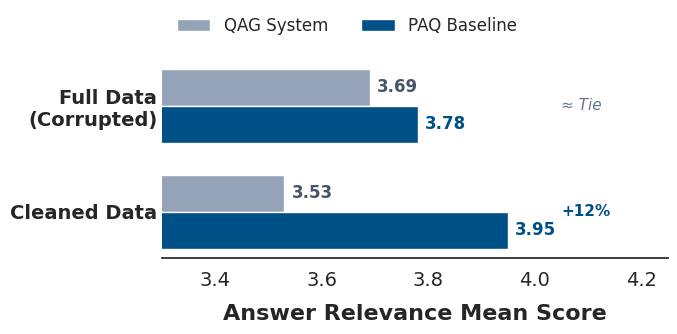

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Global typography settings for poster readability
plt.rc('font', size=14)
plt.rc('axes', labelsize=16, titlesize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)

# 2. Data
# Rows = conditions, Columns = systems (QAG, PAQ)
full_data_scores  = [3.69, 3.78]   # corrupted  → tie
clean_data_scores = [3.53, 3.95]   # cleaned    → PAQ wins

systems = ['QAG System', 'PAQ Baseline']
conditions = ['Cleaned Data', 'Full Data\n(Corrupted)']

y      = np.arange(len(conditions))   # [0, 1]  – one row per condition
width  = 0.35

fig, ax = plt.subplots(figsize=(7, 3.6))

# ── Upper row: Full Data (Corrupted) – QAG left, PAQ right ──
rects_qag_full  = ax.barh(1 + width/2, full_data_scores[0], width,
                           label='QAG System', color='#94a3b8')
rects_paq_full  = ax.barh(1 - width/2, full_data_scores[1], width,
                           label='PAQ Baseline', color='#005088')

# ── Lower row: Cleaned Data – QAG left, PAQ right ──
rects_qag_clean = ax.barh(0 + width/2, clean_data_scores[0], width,
                           color='#94a3b8')   # same colour, no duplicate label
rects_paq_clean = ax.barh(0 - width/2, clean_data_scores[1], width,
                           color='#005088')

# ── Axes & labels ──
ax.set_xlabel('Answer Relevance Mean Score', fontweight='bold', labelpad=10)
ax.set_yticks([0, 1])
ax.set_yticklabels(conditions, fontweight='bold')
ax.set_xlim(3.3, 4.25)

# ── Remove chart junk ──
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

# ── Legend (systems, not conditions) ──
ax.legend(loc='lower left', bbox_to_anchor=(0.0, 1.05),
          ncol=2, frameon=False, fontsize=12)

# ── Data labels ──
for rects, color in [(rects_qag_full,  '#475569'),
                     (rects_paq_full,  '#005088'),
                     (rects_qag_clean, '#475569'),
                     (rects_paq_clean, '#005088')]:
    ax.bar_label(rects, padding=5, fmt='%.2f',
                 fontsize=12, fontweight='bold', color=color)

# ── Story-beat annotations ──
# Beat 1 – tie (Full Data row, y = 1)
ax.text(4.05, 1, '≈ Tie', color='#64748b',
        fontsize=11, va='center', style='italic')

# Beat 2 – PAQ wins (Cleaned Data row, y = 0)
ax.text(4.05, 0, '+12%', color='#005088',
        fontsize=11, va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("images/answer_relevance_val_effect.svg", dpi=300, bbox_inches='tight')
plt.show()


## Poster: Calculate pairwise IAA

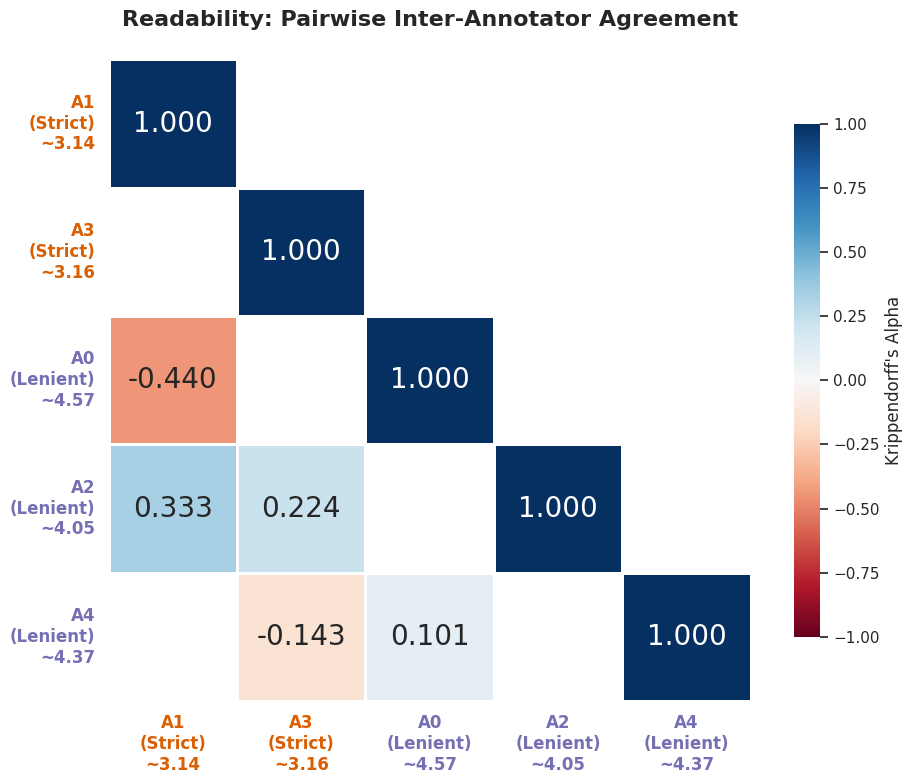

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import krippendorff
from itertools import combinations

def calculate_pairwise_krippendorff(df, qc="readability"):
    """
    Calculates a pairwise Krippendorff's alpha matrix from a long-format DataFrame.
    """
    item_col = 'qa_id' if 'qa_id' in df.columns else 'item_id'
    
    # pivot_table avoids errors if there are accidental duplicate ratings in the raw data
    wide_df = df.pivot_table(index='labeller_id', columns=item_col, values=qc)
    labellers = wide_df.index.tolist()
    
    alpha_matrix = pd.DataFrame(np.nan, index=labellers, columns=labellers)
    
    for coder1, coder2 in combinations(labellers, 2):
        pair_data = wide_df.loc[[coder1, coder2]]
        pair_data_clean = pair_data.dropna(axis=1, how='any')
        
        if pair_data_clean.shape[1] > 1:
            try:
                alpha = krippendorff.alpha(
                    reliability_data=pair_data_clean.values,
                    level_of_measurement='ordinal'
                )
                alpha_matrix.loc[coder1, coder2] = alpha
                alpha_matrix.loc[coder2, coder1] = alpha
            except ValueError:
                pass
                
    return alpha_matrix

# ==========================================
# 1. Calculate Data On-The-Fly
# ==========================================
# Make sure the 'repl_this' DataFrame is loaded here
df_long = pd.DataFrame(repl_this)

raw_alpha_matrix = calculate_pairwise_krippendorff(df_long, qc="readability")
averages = df_long.groupby("labeller_id")["readability"].mean()

annotator_info = []
for labeller_id in raw_alpha_matrix.index:
    mean_score = averages.get(labeller_id, np.nan)
    classification = "Strict" if mean_score < 3.5 else "Lenient"
    sort_key = 0 if classification == "Strict" else 1
    
    # Defend against generating 'AA1' if IDs already contain 'A'
    clean_id = str(labeller_id).replace('A', '')
    
    annotator_info.append({
        'id': clean_id,
        'original_id': labeller_id,
        'mean': mean_score,
        'class': classification,
        'sort_key': sort_key
    })

info_df = pd.DataFrame(annotator_info).sort_values(by=['sort_key', 'id'])

# Map back to exact original IDs for matrix sorting
sorted_ids = info_df['original_id'].tolist()

# ==========================================
# 2. Generate Dynamic Labels & Reorder Matrix
# ==========================================
# X-axis labels use newlines to fit horizontally
x_annotators = [f"A{row['id']}\n({row['class']})\n~{row['mean']:.2f}" for _, row in info_df.iterrows()]

# Y-axis labels remain on a single line
y_annotators = [f"A{row['id']}\n({row['class']})\n~{row['mean']:.2f}" for _, row in info_df.iterrows()]

# Reorder the matrix rows and columns using the sorted IDs
# Added .copy() here to prevent the read-only ValueError
sorted_matrix = raw_alpha_matrix.loc[sorted_ids, sorted_ids].values.copy()

# Fill the diagonal with 1.0 to anchor the matrix visually
np.fill_diagonal(sorted_matrix, 1.0)

# ==========================================
# 3. Prepare the Mask and Annotations
# ==========================================
# k=1 keeps the main diagonal visible while hiding the redundant upper triangle
mask = np.triu(np.ones_like(sorted_matrix, dtype=bool), k=1)

annot_labels = np.empty_like(sorted_matrix, dtype=object)
for i in range(sorted_matrix.shape[0]):
    for j in range(sorted_matrix.shape[1]):
        if mask[i, j] or np.isnan(sorted_matrix[i, j]):
            annot_labels[i, j] = ""
        else:
            annot_labels[i, j] = f"{sorted_matrix[i, j]:.3f}"

# ==========================================
# 4. Visualization
# ==========================================
sns.set_theme(style="white")
# Increased figsize ensures the horizontal 3-line text doesn't overlap
fig, ax = plt.subplots(figsize=(10, 8))

cmap = sns.color_palette("RdBu", as_cmap=True)

sns.heatmap(
    sorted_matrix,
    mask=mask,
    annot=annot_labels,
    fmt="",
    cmap=cmap,
    vmin=-1.0,
    vmax=1.0,
    center=0,
    square=True,
    linewidths=2,
    linecolor='white',
    cbar_kws={"shrink": .8, "label": "Krippendorff's Alpha"},
    xticklabels=x_annotators,
    yticklabels=y_annotators,
    ax=ax,
    annot_kws={"size": 20}
)

ax.set_facecolor('white')

# Dynamically color axis labels
for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
    if "Strict" in tick_label.get_text():
        tick_label.set_color("#d95f02")
    else:
        tick_label.set_color("#7570b3")
    tick_label.set_fontweight("bold")
    tick_label.set_fontsize(12)

# Force strictly horizontal text
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)

plt.title("Readability: Pairwise Inter-Annotator Agreement", fontsize=16, fontweight="bold", pad=24)
plt.tight_layout()

plt.savefig("images/dynamic_clean_iaa_matrix.svg", dpi=300, bbox_inches='tight')
plt.show()